In [1]:
# Importing Libraries
import seaborn as sns
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_DS_USA= df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Scientist')]

df_DS_USA =df_DS_USA.dropna(subset=['salary_year_avg'])

df_DS_USA_explode = df_DS_USA.explode('job_skills')



In [3]:
df_DS_skills = (
    df_DS_USA_explode.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .rename(columns={'count': 'skill_count', 'median': 'median_salary'})
    .sort_values(by='skill_count', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'job_skills': 'skill'})
)

DS_job_count = len(df_DS_USA)
df_DS_skills['skill_percent'] = (df_DS_skills['skill_count'] / DS_job_count) * 100

skill_limit = 5
df_DS_skills_high_demand = df_DS_skills[df_DS_skills['skill_percent'] >= skill_limit]

df_DS_skills_high_demand

,skill,skill_count,median_salary,skill_percent
0,python,3358,131867.0,73.753569
1,sql,2463,134500.0,54.096200
2,r,2053,126000.0,45.091149
3,sas,1022,120000.0,22.446738
4,tableau,989,125000.0,21.721942
5,aws,768,134000.0,16.867999
6,spark,718,135959.5,15.769822
7,excel,490,124290.0,10.762135
8,tensorflow,474,149646.0,10.410718
9,hadoop,468,125000.0,10.278937


In [5]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spss',
  'tableau',
  'alteryx',
  'powerpoint',
  'excel',
  'ssis',
  'datarobot',
  'nuix',
  'msaccess',
  'visio',
  'dax',
  'esquisse',
  'cognos',
  'sheets',
  'power bi',
  'word',
  'qlik',
  'splunk',
  'microstrategy',
  'looker',
  'spreadsheet',
  'ssrs',
  'sas',
  'powerbi',
  'ms access',
  'sap',
  'sharepoint',
  'outlook'],
 'programming': ['objective-c',
  'c++',
  'vb.net',
  'html',
  'powershell',
  'f#',
  'crystal',
  'typescript',
  'no-sql',
  'clojure',
  'lua',
  'erlang',
  'kotlin',
  'css',
  'go',
  'sql',
  'delphi',
  'solidity',
  'golang',
  'groovy',
  'assembly',
  'haskell',
  'python',
  'ocaml',
  'visualbasic',
  'perl',
  'visual basic',
  'java',
  'dart',
  'php',
  'sass',
  't-sql',
  'julia',
  'rust',
  'pascal',
  'c',
  'elixir',
  'javascript',
  'lisp',
  'mongo',
  'matlab',
  'shell',
  'sas',
  'r',
  'apl',
  'fortran',
  'cobol',
  'bash',
  'vba',
  'nosql',
  'mongodb',
  'scala',
  'swift',
  'c#',
  'r

In [6]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spss
0,analyst_tools,tableau
0,analyst_tools,alteryx
0,analyst_tools,powerpoint
0,analyst_tools,excel
...,...,...
9,sync,google chat
9,sync,microsoft teams
9,sync,slack
9,sync,mattermost


In [9]:
# merge df_DA_skills and df_technology
df_DS_skills_tech = df_DS_skills.merge(df_technology, left_on='skill', right_on='skills')

df_DS_skills_tech

,skill,skill_count,median_salary,skill_percent,technology,skills
0,python,3358,131867.0,73.753569,programming,python
1,sql,2463,134500.0,54.096200,programming,sql
2,r,2053,126000.0,45.091149,programming,r
3,sas,1022,120000.0,22.446738,analyst_tools,sas
4,sas,1022,120000.0,22.446738,programming,sas
5,tableau,989,125000.0,21.721942,analyst_tools,tableau
6,aws,768,134000.0,16.867999,cloud,aws
7,spark,718,135959.5,15.769822,libraries,spark
8,excel,490,124290.0,10.762135,analyst_tools,excel
9,tensorflow,474,149646.0,10.410718,libraries,tensorflow


In [10]:
df_DS_skills_tech_high_demand = df_DS_skills_tech[df_DS_skills_tech['skill_percent'] > skill_limit]

<Figure size 640x480 with 0 Axes>

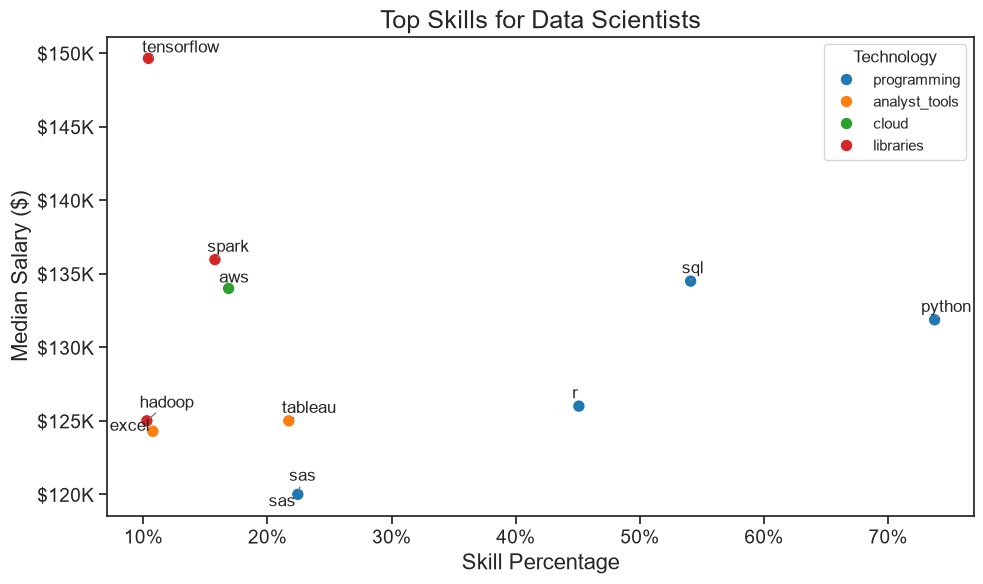

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

sns.set_theme(style='ticks')
sns.despine()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=df_DS_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    palette='tab10',
    s=80
)

# Label each point with the skill name
texts = []
for _, row in df_DS_skills_tech_high_demand.iterrows():
    texts.append(
        plt.text(
            row['skill_percent'],
            row['median_salary'],
            row['skill'],
            fontsize=12,
            ha='right',
            va='bottom'
        )
    )

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax.set_title('Top Skills for Data Scientists', fontsize=18)
ax.set_xlabel('Skill Percentage', fontsize=16)
ax.set_ylabel('Median Salary ($)', fontsize=16)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y / 1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.legend(title='Technology')
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()